In [1]:
import os
import torch
import torch.nn as nn
import torch.optim.swa_utils as swa_utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import seaborn as sns

from albumentations.pytorch import ToTensorV2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision.transforms import v2
from tqdm.auto import tqdm

In [2]:
assert torch.cuda.is_available()
device = 'cuda'

In [3]:
data_path = './data/'
image_dir = os.path.join(data_path, 'images')
gt_dir = os.path.join(data_path, 'gt.csv')

In [4]:
def generate_heatmap(size, keypoints, sigma):
    """Создает стек тепловых карт (N, H, W)"""
    h, w = size
    num_points = keypoints.shape[0]
    heatmaps = np.zeros((num_points, h, w), dtype=np.float32)

    for i, (x, y) in enumerate(keypoints):
        # if x < 0 or y < 0 or x >= w or y >= h:
        #     continue
        xx, yy = np.meshgrid(np.arange(w), np.arange(h))
        heatmaps[i] = np.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2))

    return heatmaps

In [5]:
class FaceImageDataset(Dataset):
    def __init__(self, image_dir, gt_dir, img_size, transform: v2.Transform, sigma):
        self.image_dir = image_dir
        self.image_files = os.listdir(image_dir)
        self.transform = transform
        self.targets = pd.read_csv(gt_dir, index_col='filename')
        self.img_size = img_size
        self.sigma = sigma

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_file)
        image = np.array(Image.open(img_path).convert('RGB'))

        keypoints = self.targets.loc[img_file].to_numpy().reshape(-1, 2)
        transformed = self.transform(image=image, keypoints=keypoints)
        target = transformed['keypoints']

        target = generate_heatmap(self.img_size, target, sigma=self.sigma)
        return transformed['image'], torch.Tensor(target)

In [6]:
def remap_keypoints(keypoints, **_):
    flip_mapping = [3, 2, 1, 0, 9, 8, 7, 6, 5, 4, 10, 13, 12, 11]
    return keypoints[flip_mapping]

In [ ]:
batch_size = 32
num_workers = 0
img_size = (100, 100)
flip_mapping = [3, 2, 1, 0, 9, 8, 7, 6, 5, 4, 10, 13, 12, 11]

transforms = A.Compose([
    A.OneOf([
        A.Compose([
            A.HorizontalFlip(p=1.0),
            A.Lambda(keypoints=remap_keypoints),
        ], p=0.5),
        A.NoOp(p=0.5),
    ]),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, border_mode=0, p=0.8),
    A.RandomResizedCrop(size=img_size, scale=(0.8, 1), p=1.0),

    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.8),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    ], p=0.7),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.GaussNoise(std_range=(0.03, 0.07), p=0.3),
    # A.CoarseDropout(max_holes=5, max_height=16, max_width=16, p=0.5),

    A.Normalize(mean=[0.5364, 0.4303, 0.3750], std=[0.2378, 0.2182, 0.2084]),
    ToTensorV2(),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

val_transforms = A.Compose([
    A.Resize(*img_size),
    A.Normalize(mean=[0.5364, 0.4303, 0.3750], std=[0.2378, 0.2182, 0.2084]),
    ToTensorV2(),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

dataset = FaceImageDataset(image_dir, gt_dir, img_size=img_size, transform=transforms, sigma=2)
train_dataset, val_dataset = torch.utils.data.random_split(dataset, (0.7, 0.3))
val_dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

/home/revit3d/.cache/pypoetry/virtualenvs/vmk-qg3DzDu0-py3.13/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
def visualize(inputs, targets, outputs=None, n=16):
    idxs = np.random.randint(0, len(inputs), size=n)

    fig, axes = plt.subplots(int(n**0.5), int(n**0.5), figsize=(20, 20))
    axes = np.ravel(axes)

    for i, idx in enumerate(idxs):
        target = targets[idx]  # denormalize
        xs = [target[j] for j in range(0, len(target), 2)]
        ys = [target[j] for j in range(1, len(target), 2)]
        axes[i].imshow(inputs[idx].permute(1, 2, 0).clip(0, 1))
        axes[i].scatter(xs, ys, c='r')
        for j in range(len(xs)):
            axes[i].text(xs[j] + 1, ys[j] + 1, str(j), c='r')
        if outputs is not None:
            output = outputs[idx]  # denormalize
            assert len(outputs) == len(targets), f'{outputs.shape}, {targets.shape}'
            xs = [output[j] for j in range(0, len(output), 2)]
            ys = [output[j] for j in range(1, len(output), 2)]
            axes[i].scatter(xs, ys, c='g')
            for j in range(len(xs)):
                axes[i].text(xs[j] + 1, ys[j] + 1, str(j), c='g')
        axes[i].axis('off')
    return fig


def heatmaps_to_coords(heatmaps):
    b, n, h, w = heatmaps.shape
    heatmaps_reshaped = heatmaps.view(b, n, -1)
    max_idx = heatmaps_reshaped.argmax(-1)
    y = (max_idx // w).float()
    x = (max_idx % w).float()
    coords = torch.stack((x, y), dim=-1)
    return coords


def visualize_heatmaps(inputs, targets, outputs):
    idx = np.random.randint(0, len(inputs))

    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    axes = np.ravel(axes)

    target = heatmaps_to_coords(targets)[idx].flatten(-2, -1).numpy()
    xs = [target[j] for j in range(0, len(target), 2)]
    ys = [target[j] for j in range(1, len(target), 2)]
    axes[0].imshow(inputs[idx].permute(1, 2, 0).clip(0, 1))
    axes[0].scatter(xs, ys, c='r')
    for j in range(len(xs)):
        axes[0].text(xs[j] + 1, ys[j] + 1, str(j), c='r')
    axes[0].axis('off')

    output = outputs[idx]
    for i in range(14):
        heatmap = output[i].numpy()
        sns.heatmap(heatmap, ax=axes[i + 1], cbar=False)
        axes[i + 1].axis('off')
    return fig

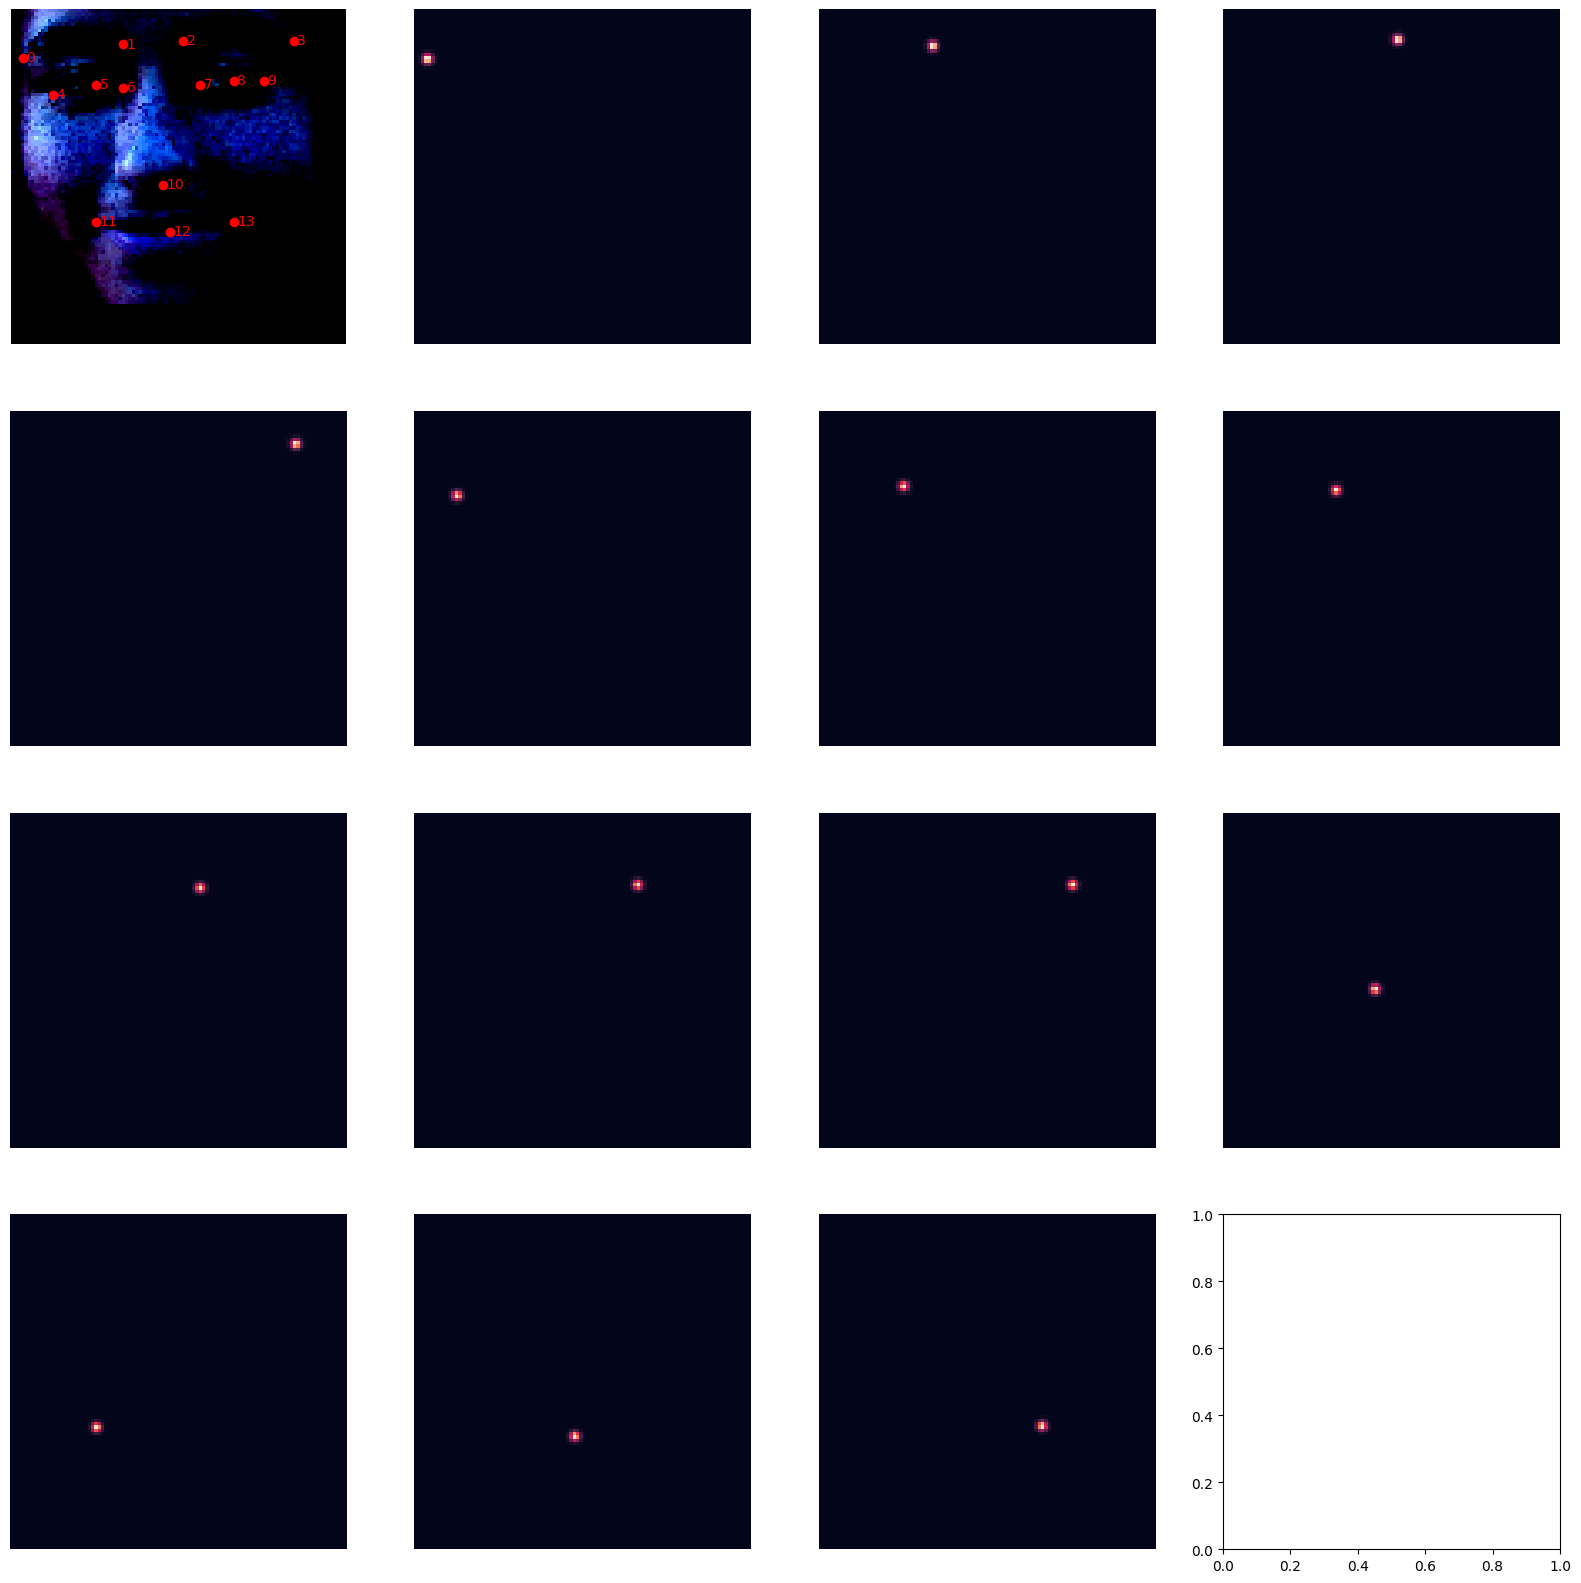

In [9]:
inputs, targets = next(iter(train_loader))
# visualize(inputs, heatmaps_to_coords(targets).flatten(1, -1))
visualize_heatmaps(inputs, targets, targets)
plt.show()

In [10]:
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.SiLU(),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.se = SEBlock(out_ch)
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(),
        )
        # Add a 1x1 conv if channel dimensions don't match for the residual
        if in_ch == out_ch:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x):
        res = self.residual(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.se(x)
        return x + res


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_landmarks=14):
        super().__init__()

        self.enc1 = UNetBlock(in_channels, 16)
        self.enc2 = UNetBlock(16, 32)
        self.enc3 = UNetBlock(32, 64)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = UNetBlock(64, 128)

        self.up3 = nn.Sequential(
            nn.Upsample(size=(25, 25), mode='bilinear', align_corners=True),
            nn.Conv2d(128, 64, kernel_size=1) # Or kernel_size=1
        )
        self.dec3 = UNetBlock(128, 64)
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(64, 32, kernel_size=1) # Or kernel_size=1
        )
        self.dec2 = UNetBlock(64, 32)
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(32, 16, kernel_size=1) # Or kernel_size=1
        )
        self.dec1 = UNetBlock(32, 16)

        self.final = nn.Conv2d(16, num_landmarks, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        return self.sigmoid(out)  # (B, num_landmarks, H, W)

In [11]:
def weighted_mse_loss(pred, target, weight_factor=10.0):
    """
    Gives more weight to the positive areas of the heatmap (the Gaussian peaks).
    """
    weight = torch.ones_like(target)
    # Increase weight for pixels with higher values in the target (i.e., near keypoints)
    weight[target > 0.1] = weight_factor
    loss = torch.mean(weight * (pred - target) ** 2)
    return loss

In [12]:
class Trainer:
    def __init__(
        self,
        model: nn.Module,
        criterion: nn.Module,
        optimizer: torch.optim.Optimizer,
        scheduler = None,
        logger: SummaryWriter | None = None,
        device: str | torch.device = 'cpu',
    ):
        self.model = model
        # self.ema_model = swa_utils.AveragedModel(model, avg_fn=lambda avg, new, n: 0.999 * avg + 0.001 * new)
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.logger = logger
        self.device = device

    def step(self, inputs, targets, model=None) -> torch.Tensor:
        if model is None:
            model = self.model
        inputs = inputs.to(self.device)
        targets = targets.to(self.device)
        output = model(inputs)
        loss = self.criterion(output, targets)
        return loss, output

    @torch.no_grad
    def validate(self, loader, step, ema=False):
        if ema:
            self.ema_model.module.eval()
        else:
            self.model.eval()

        loss_total = 0
        for inputs, targets in loader:
            _, output = self.step(inputs, targets, self.ema_model.module if ema else None)
            target_coo = heatmaps_to_coords(targets.cpu())
            output_coo = heatmaps_to_coords(output.cpu())
            loss_total += nn.functional.mse_loss(target_coo, output_coo)
        loss_total /= len(loader)
        loss_total = loss_total.cpu().item()

        if self.logger:
            self.logger.add_scalar(f'Loss/Validation{'_ema' if ema else ''}', loss_total, global_step=step)

        if ema:
            self.ema_model.module.train()
        else:
            self.model.train()

        return loss_total

    def train(self, train_loader: DataLoader, val_loader: DataLoader, n_epochs: int):
        self.model.train()
        # self.ema_model.module.train()

        val_losses = []
        ema_val_losses = []
        for epoch in tqdm(range(n_epochs)):
            last_output = None
            for i, (inputs, targets) in enumerate(train_loader):
                loss, last_output = self.step(inputs, targets)
                self.optimizer.zero_grad()
                loss.backward()
                #torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)
                self.optimizer.step()
                # self.ema_model.update_parameters(self.model)
                if self.logger:
                    global_step = epoch * len(train_loader) + i
                    self.logger.add_scalar(
                        'Loss/Train', loss.item(), global_step,
                    )
                    if self.scheduler:
                        self.logger.add_scalar("Scheduler/lr", self.scheduler.get_last_lr()[0], global_step)
                if self.scheduler:
                    self.scheduler.step()
            if self.logger:
                target_coo = heatmaps_to_coords(targets.cpu())
                output_coo = heatmaps_to_coords(last_output.detach().cpu())
                fig = visualize(inputs, target_coo.flatten(1, -1), output_coo.flatten(1, -1))
                self.logger.add_figure('Examples/Faces', fig, epoch)
                fig = visualize_heatmaps(inputs, targets, last_output.detach().cpu())
                self.logger.add_figure('Examples/Heatmaps', fig, epoch)

            val_loss = self.validate(val_loader, step=epoch, ema=False)
            # ema_val_loss = self.validate(val_loader, step=epoch, ema=True)
            val_losses.append(val_loss)
            # ema_val_losses.append(ema_val_loss)

        self.model.eval()
        # self.ema_model.module.eval()

        return val_losses, ema_val_losses

In [13]:
hparams = {
    "sigma": 2,
    "optimizer": "AdamW",
    "lr": 5e-4,
    "weight_decay": 5e-4,
    "batch_size": 32,
    "img_size": "100x100",
    "scheduler": "OneCycleLR",
    "max_lr": 5e-3,
    "grad_clip": 1.0,
    "epochs": 50,
}

In [14]:
model = UNet()
# ema_model = swa_utils.AveragedModel(model, avg_fn=lambda avg, new, n: 0.999 * avg + 0.001 * new)
optimizer = torch.optim.AdamW(model.parameters(), lr=hparams['lr'], weight_decay=hparams['weight_decay'])
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=hparams['max_lr'],
    steps_per_epoch=len(train_loader),
    epochs=hparams['epochs'],
)
logger = SummaryWriter(log_dir='./logs/exp_model_heatmap2')
trainer = Trainer(
    model=model.to(device),
    criterion=weighted_mse_loss,
    optimizer=optimizer,
    scheduler=scheduler,
    logger=logger,
    device=device,
)
sum(p.numel() for p in model.parameters())

486174

In [ ]:
val_losses, ema_val_losses = trainer.train(train_loader, val_loader, n_epochs=hparams['epochs'])
logger.add_hparams(hparams, {"val_loss": val_losses[-1]})
logger.close()

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
torch.save(
    {
        'epoch': hparams['epochs'],
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_losses[-1],
    },
    './checkpoints/pretrained_model_checkpoint_0.pt',
)